In [1]:
#Packages
import os
import json
import time
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\GPT_DatasetA_Processed.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\GPT_DatasetB_Processed.csv")

#Importing OpenAI API
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_KEY")
client = OpenAI()

#Pydantic Validation: Hard structures for the continuous sentiment scores
class FinancialSentiment(BaseModel):
    positive: float = Field(description="Probability score for positive sentiment, between 0.0 and 1.0")
    negative: float = Field(description="Probability score for negative sentiment, between 0.0 and 1.0")
    neutral: float = Field(description="Probability score for neutral sentiment, between 0.0 and 1.0")

In [3]:
#Chunk Generation and Cloud Cluster Deployment
def process_news_datasets(df, dataset_name, text_column='gpt_input'):
    """
    Slices highly dense financial news datasets into safe, 15,000-row chunks 
    to guarantee payload sizes stay securely under the 200 MB gateway limits.
    """
    total_rows = len(df)
    CHUNK_SIZE = 15000 
    batch_ids = []
    
    #Custom Prompt
    system_prompt = (
        """You are an expert financial NLP system specializing in financial journalism. Analyze the provided financial news text segment
        and determine the exact probability distribution for Positive, Negative, and Neutral sentiment based on macroeconomics, market impacts,
        and corporate asset valuation realities. Evaluate the text as an independent unit."""
    )
    
    #Extracts the base dictionary layout from Pydantic
    json_schema = FinancialSentiment.model_json_schema()
    json_schema["additionalProperties"] = False  #Enforces rigid schema compliance
    
    chunks = [df[i:i + CHUNK_SIZE] for i in range(0, total_rows, CHUNK_SIZE)]

    for idx, chunk_df in enumerate(chunks):
        local_filename = f"{dataset_name}_part_{idx + 1}_batch_input.jsonl"
        
        with open(local_filename, 'w') as f:
            for index_anchor, row in chunk_df.iterrows():
                raw_text = str(row[text_column]).strip()
                if not raw_text:
                    continue  #Protects against blank or missing data rows
                
                request_data = {
                    "custom_id": f"idx_{index_anchor}",  #Maps index for left-join
                    "method": "POST",
                    "url": "/v1/chat/completions",
                    "body": {
                        "model": "gpt-4o-mini",
                        "temperature": 0.0,
                        "response_format": {
                            "type": "json_schema",
                            "json_schema": {
                                "name": "financial_sentiment_schema",
                                "strict": True,
                                "schema": json_schema
                            }
                        },
                        "messages": [
                            {"role": "system", "content": system_prompt},
                            {"role": "user", "content": raw_text}
                        ]
                    }
                }
                f.write(json.dumps(request_data) + '\n')
        
        print(f"Generated local file: {local_filename}")
        
        #Stream payload to the cloud cluster queue
        with open(local_filename, "rb") as file_stream:
            batch_file = client.files.create(file=file_stream, purpose="batch")
        
        job = client.batches.create(
            input_file_id=batch_file.id,
            endpoint="/v1/chat/completions",
            completion_window="24h"
        )
        
        print(f"[Chunk {idx + 1}/{len(chunks)}] Dispatched to Cloud Cluster. Batch ID: {job.id}")
        batch_ids.append(job.id)
        time.sleep(1) 
            
    return batch_ids

In [4]:
#Deployment Pipeline:
#Launching dataset A split into chunks
ids_datasetA = process_news_datasets(dataset_A, dataset_name="dataset_A", text_column="gpt_input")

#Launching the dataset B split into chunks
ids_datasetB = process_news_datasets(dataset_B, dataset_name="dataset_B", text_column="gpt_input")

print("Tracking IDs")
print(f"DatasetA News Corpus Tracking IDs: {ids_datasetA}")
print(f"DatasetB News Corpus Tracking IDs: {ids_datasetB}")

Generated local file: dataset_A_part_1_batch_input.jsonl
[Chunk 1/5] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8cf7f6f08190a5d7ff7cf7ed30d0
Generated local file: dataset_A_part_2_batch_input.jsonl
[Chunk 2/5] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8d1c58d08190800051591c9c4692
Generated local file: dataset_A_part_3_batch_input.jsonl
[Chunk 3/5] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8d40b47481909f1b824644f2dc16
Generated local file: dataset_A_part_4_batch_input.jsonl
[Chunk 4/5] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8d5adfec819098a8315c8e9f1ccb
Generated local file: dataset_A_part_5_batch_input.jsonl
[Chunk 5/5] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8d5deee0819084d60d1f2a468662
Generated local file: dataset_B_part_1_batch_input.jsonl
[Chunk 1/3] Dispatched to Cloud Cluster. Batch ID: batch_6a4a8d7fa754819096df6a954f08ea0b
Generated local file: dataset_B_part_2_batch_input.jsonl
[Chunk 2/3] Dispatched to Cloud Cluster. Batch ID: batch_6a4a

In [5]:
#Progress Tracking
def check_batch_status(batch_id):
    """Checks and reports the exact current status of an ongoing batch job."""
    job = client.batches.retrieve(batch_id)
    print(f"Job ID: {batch_id} | Status: '{job.status}'")
    if job.request_counts:
        print(f"Progress: {job.request_counts.completed}/{job.request_counts.total} processed.")
    if job.status == "completed":
        print(f"Success! Downloadable File ID is: {job.output_file_id}")
    return job.status, job.output_file_id

In [6]:
#Execution stopwatch
start_time = time.time()

while True:
    clear_output(wait=True)
    all_chunks_completed = True
    elapsed_seconds = time.time() - start_time
    elapsed_formatted = time.strftime("%H:%M:%S", time.gmtime(elapsed_seconds))
    
    print(f"Monitoring Dashboard")
    print(f"Total Time Elapsed: {elapsed_formatted} ({elapsed_seconds:.2f} seconds)")
    
    #Dataset A Chunks
    print("\n[Dataset A]")
    for b_id in ids_datasetA:
        status, _ = check_batch_status(b_id)
        if status != "completed":
            all_chunks_completed = False
            
    #Dataset B Chunks
    print("\n[Dataset B]")
    for b_id in ids_datasetB:
        status, _ = check_batch_status(b_id)
        if status != "completed":
            all_chunks_completed = False
    
    #Terminates the loop automatically if everything is processed
    if all_chunks_completed:
        print(f"\n All chunks completed.")
        print(f"Inference loop successfully concluded in {elapsed_seconds:.2f} seconds.")
        break
    time.sleep(30)

Monitoring Dashboard
Total Time Elapsed: 00:45:55 (2755.29 seconds)

[Dataset A]
Job ID: batch_6a4a8cf7f6f08190a5d7ff7cf7ed30d0 | Status: 'completed'
Progress: 15000/15000 processed.
Success! Downloadable File ID is: file-BN7ikTr22z2wAohsVhKoXp
Job ID: batch_6a4a8d1c58d08190800051591c9c4692 | Status: 'completed'
Progress: 15000/15000 processed.
Success! Downloadable File ID is: file-CsABeSwPTAYC3EkHo3YXR2
Job ID: batch_6a4a8d40b47481909f1b824644f2dc16 | Status: 'completed'
Progress: 15000/15000 processed.
Success! Downloadable File ID is: file-PoaG8XwSTht6aqV73agJ6o
Job ID: batch_6a4a8d5adfec819098a8315c8e9f1ccb | Status: 'completed'
Progress: 15000/15000 processed.
Success! Downloadable File ID is: file-GKEGBTdd2hSQYMnjDNRHk4
Job ID: batch_6a4a8d5deee0819084d60d1f2a468662 | Status: 'completed'
Progress: 903/903 processed.
Success! Downloadable File ID is: file-3u8wW7fTvPU79tvnc5e4Qd

[Dataset B]
Job ID: batch_6a4a8d7fa754819096df6a954f08ea0b | Status: 'completed'
Progress: 15000/15000

In [7]:
#Output Compilation
def download_and_compile_features(output_file_id, original_df):
    file_response = client.files.content(output_file_id)
    parsed_results = []
    
    #Process the returned strings line-by-line
    for line in file_response.text.strip().split('\n'):
        if not line:
            continue
        data = json.loads(line)
        
        #Pulls original DataFrame index from the custom_id key
        custom_id = data.get("custom_id", "")
        row_idx = int(custom_id.split("_")[1])
        
        #Extracts model outputs
        response_body = data["response"]["body"]["choices"][0]["message"]["content"]
        sentiment_data = json.loads(response_body)
        
        p_pos = sentiment_data.get("positive", 0.0)
        p_neg = sentiment_data.get("negative", 0.0)
        p_neu = sentiment_data.get("neutral", 0.0)
        
        #Calculates continuous net sentiment and categorical hard labels
        gpt_net_sentiment = p_pos - p_neg
        
        channels = [p_neg, p_neu, p_pos]
        max_idx = np.argmax(channels)
        
        if max_idx == 0:
            gpt_hard_label = -1
        elif max_idx == 1:
            gpt_hard_label = 0
        else:
            gpt_hard_label = 1
            
        parsed_results.append({
            "index_anchor": row_idx,
            "gpt_pos": p_pos,
            "gpt_neg": p_neg,
            "gpt_neu": p_neu,
            "gpt_net_sentiment": gpt_net_sentiment,
            "gpt_hard_label": gpt_hard_label
        })
        
    #Build feature matrix dataframe
    gpt_features_df = pd.DataFrame(parsed_results).set_index("index_anchor")
    
    #Left join back to original input container to ensure 100% data alignment preservation
    final_merged_df = original_df.join(gpt_features_df, how="left")
    print(f"Compilation complete!")
    return final_merged_df

In [10]:
#Output Compilation
#Assembling all dataset A chunks
file_ids_dataset_A = [
    "file-BN7ikTr22z2wAohsVhKoXp",
    "file-CsABeSwPTAYC3EkHo3YXR2",
    "file-PoaG8XwSTht6aqV73agJ6o",
    "file-GKEGBTdd2hSQYMnjDNRHk4",
    "file-3u8wW7fTvPU79tvnc5e4Qd"
]
results_list_A = []

for file_id in file_ids_dataset_A:
    print(f"Downloading cloud file: {file_id}")
    file_response = client.files.content(file_id)
    
    for line in file_response.text.strip().split('\n'):
        if not line: 
            continue
        data = json.loads(line)
        row_idx = int(data["custom_id"].split("_")[1])
        sentiment_data = json.loads(data["response"]["body"]["choices"][0]["message"]["content"])
        
        p_pos = sentiment_data.get("positive", 0.0)
        p_neg = sentiment_data.get("negative", 0.0)
        p_neu = sentiment_data.get("neutral", 0.0)
        
        channels = [p_neg, p_neu, p_pos]
        max_idx = np.argmax(channels)
        gpt_hard_label = -1 if max_idx == 0 else (0 if max_idx == 1 else 1)
        
        results_list_A.append({
            "index_anchor": row_idx,
            "gpt_pos": p_pos,
            "gpt_neg": p_neg,
            "gpt_neu": p_neu,
            "gpt_net_sentiment": p_pos - p_neg,
            "gpt_hard_label": gpt_hard_label
        })

#Consolidated feature matrix for Dataset A
features_df_A = pd.DataFrame(results_list_A).set_index("index_anchor")

#Drops columns if they exist from any previous failed runs to clear memory
dataset_A_clean = dataset_A.drop(columns=[c for c in features_df_A.columns if c in dataset_A.columns], errors='ignore')
dataset_A_final = dataset_A_clean.join(features_df_A, how="left")
print(f"Dataset A Completed! Shape: {dataset_A_final.shape}\n")


#Assembling all dataset B chunks
file_ids_dataset_B = [
    "file-DMazQhKfjf4mPLMRfcuGP7",
    "file-CqUFQNXYTJiL6oyfPdfbYU",
    "file-23E5mg9L57yBZncMvW7scg"
]
results_list_B = []

for file_id in file_ids_dataset_B:
    print(f"Downloading cloud file: {file_id}")
    file_response = client.files.content(file_id)
    
    for line in file_response.text.strip().split('\n'):
        if not line: 
            continue
        data = json.loads(line)
        row_idx = int(data["custom_id"].split("_")[1])
        sentiment_data = json.loads(data["response"]["body"]["choices"][0]["message"]["content"])
        
        p_pos = sentiment_data.get("positive", 0.0)
        p_neg = sentiment_data.get("negative", 0.0)
        p_neu = sentiment_data.get("neutral", 0.0)
        
        channels = [p_neg, p_neu, p_pos]
        max_idx = np.argmax(channels)
        gpt_hard_label = -1 if max_idx == 0 else (0 if max_idx == 1 else 1)
        
        results_list_B.append({
            "index_anchor": row_idx,
            "gpt_pos": p_pos,
            "gpt_neg": p_neg,
            "gpt_neu": p_neu,
            "gpt_net_sentiment": p_pos - p_neg,
            "gpt_hard_label": gpt_hard_label
        })

#Consolidated feature matrix for Dataset B
features_df_B = pd.DataFrame(results_list_B).set_index("index_anchor")

#Drops columns if they exist from any previous failed runs to clear memory
dataset_B_clean = dataset_B.drop(columns=[c for c in features_df_B.columns if c in dataset_B.columns], errors='ignore')
dataset_B_final = dataset_B_clean.join(features_df_B, how="left")
print(f"Dataset B Completed! Shape: {dataset_B_final.shape}\n")

Dataset A Completed! Shape: (60903, 15)

Dataset B Completed! Shape: (42724, 18)



In [11]:
dataset_A_final.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,gpt_input,gpt_input_len,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,TITLE: ADSK Quantitative Stock Analysis\n\nBOD...,461,0.75,0.10,0.15,0.65,1
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,TITLE: Artificial Intelligence Adding New Dept...,1442,0.85,0.05,0.10,0.80,1


In [12]:
#Checking Data types and verifying no missing values - Dataset A
sentiment_cols = ['gpt_pos','gpt_neg','gpt_neu','gpt_net_sentiment']
print(dataset_A_final[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 60903 entries, 0 to 60902
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gpt_pos            60903 non-null  float64
 1   gpt_neg            60903 non-null  float64
 2   gpt_neu            60903 non-null  float64
 3   gpt_net_sentiment  60903 non-null  float64
dtypes: float64(4)
memory usage: 1.9 MB
None


In [13]:
#Range Validation - Dataset A
print("Net Sentiment Metric Summary Statistics")
display(dataset_A_final['gpt_net_sentiment'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -1.000000
mean    0.299974
max     0.800000
Name: gpt_net_sentiment, dtype: float64

In [14]:
dataset_B_final.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month,gpt_input,gpt_input_len,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1,TITLE: The Fire Within Netflix Stock Still Bur...,869,0.65,0.15,0.2,0.5,1
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1,TITLE: Don’t Let the Class-Action Suit Dissuad...,952,0.65,0.25,0.1,0.4,1


In [15]:
#Checking Data types and verifying no missing values - Dataset B
sentiment_cols = ['gpt_pos','gpt_neg','gpt_neu','gpt_net_sentiment']
print(dataset_B_final[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 42724 entries, 0 to 42723
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gpt_pos            42724 non-null  float64
 1   gpt_neg            42724 non-null  float64
 2   gpt_neu            42724 non-null  float64
 3   gpt_net_sentiment  42724 non-null  float64
dtypes: float64(4)
memory usage: 1.3 MB
None


In [16]:
#Range Validation - Dataset B
print("Net Sentiment Metric Summary Statistics")
display(dataset_B_final['gpt_net_sentiment'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -0.900000
mean    0.317052
max     0.800000
Name: gpt_net_sentiment, dtype: float64

In [17]:
#The Zero-Sentiment Neutrality Check - Dataset A
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rateA = (dataset_A_final['gpt_net_sentiment'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rateA:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 0.76% of the corpus is perfectly neutral.


In [18]:
#The Zero-Sentiment Neutrality Check - Dataset B
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rateB = (dataset_B_final['gpt_net_sentiment'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rateB:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 0.50% of the corpus is perfectly neutral.


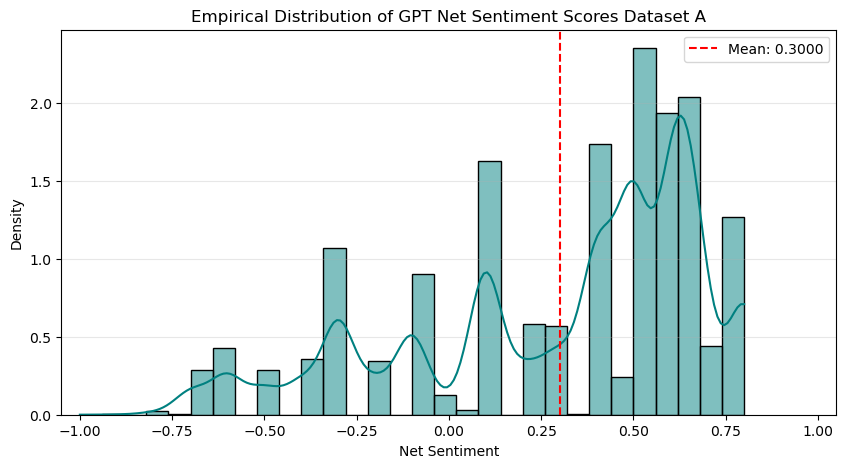

In [28]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(dataset_A_final['gpt_net_sentiment'], bins=30, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(dataset_A_final['gpt_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {dataset_A_final['gpt_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of GPT Net Sentiment Scores Dataset A', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution GPT Dataset A.png', dpi=300)
plt.show()

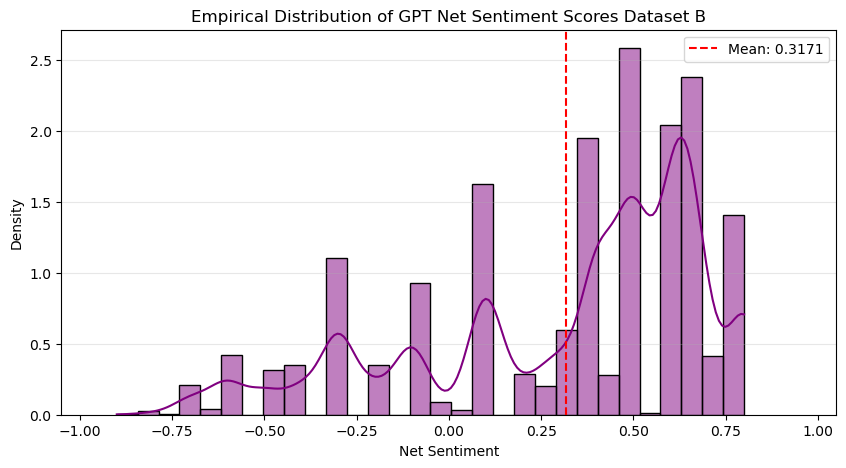

In [30]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(dataset_B_final['gpt_net_sentiment'], bins=30, kde=True, color='purple', stat='density')

#Adding a vertical line for the mean
plt.axvline(dataset_B_final['gpt_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {dataset_B_final['gpt_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of GPT Net Sentiment Scores Dataset B', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution GPT Dataset B.png', dpi=300)
plt.show()

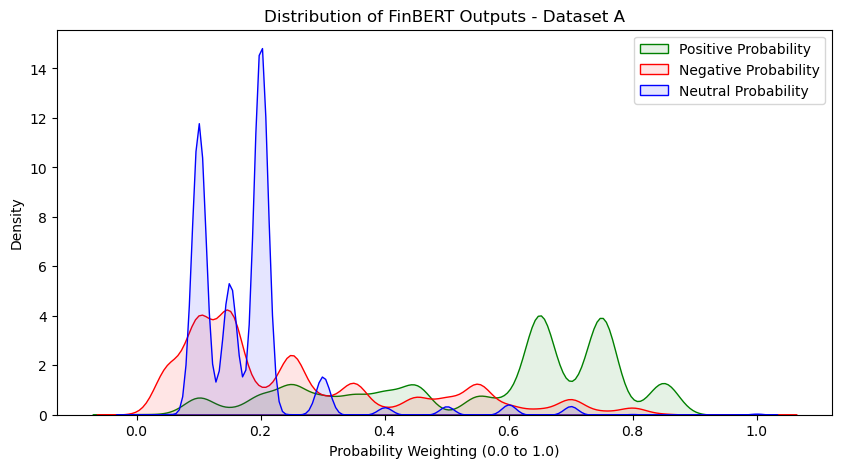

In [21]:
#Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(dataset_A_final['gpt_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(dataset_A_final['gpt_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(dataset_A_final['gpt_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of FinBERT Outputs - Dataset A', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
#plt.savefig('Distribution of FinBERT Outputs - Dataset A.png', dpi=300)
plt.show()

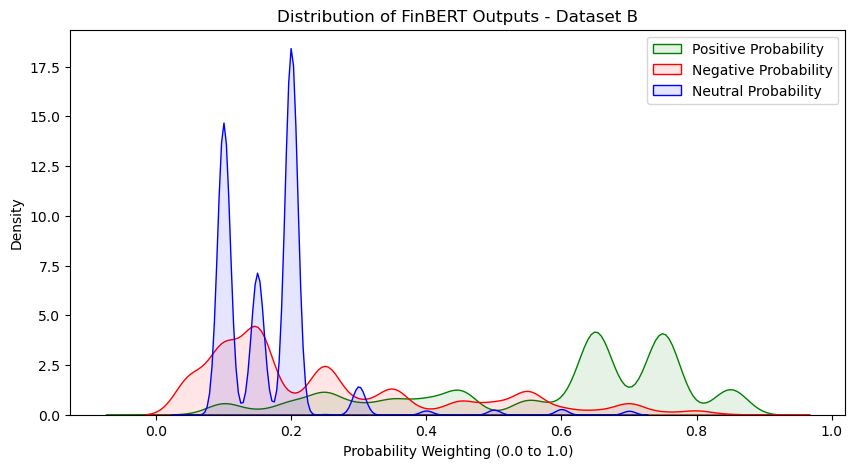

In [22]:
#Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(dataset_B_final['gpt_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(dataset_B_final['gpt_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(dataset_B_final['gpt_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of FinBERT Outputs - Dataset B', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
#plt.savefig('Distribution of FinBERT Outputs - Dataset B.png', dpi=300)
plt.show()

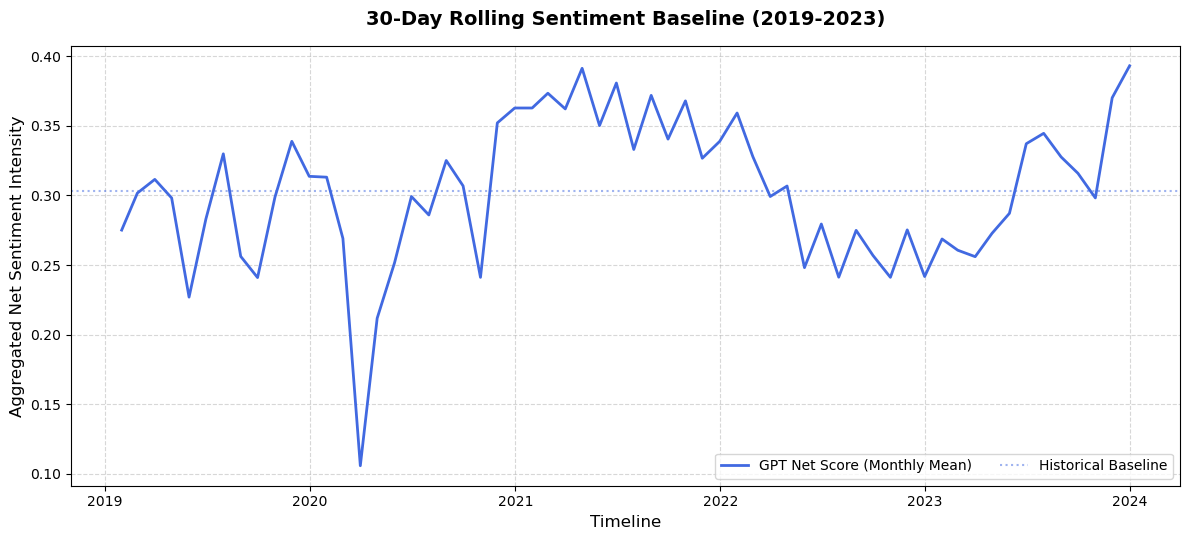

In [23]:
#Sentiment Trajectory Plot
time_df = dataset_A_final[['Date', 'gpt_net_sentiment']].copy()
time_df['Date'] = pd.to_datetime(time_df['Date'])
time_df.set_index('Date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['gpt_net_sentiment'], label='GPT Net Score (Monthly Mean)', color='royalblue', linewidth=2)
plt.axhline(y=monthly_sentiment['gpt_net_sentiment'].mean(), color='royalblue', linestyle=':', alpha=0.5, label='Historical Baseline')
plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('finbert_macro_sentiment_timeline.png', dpi=300)
plt.show()

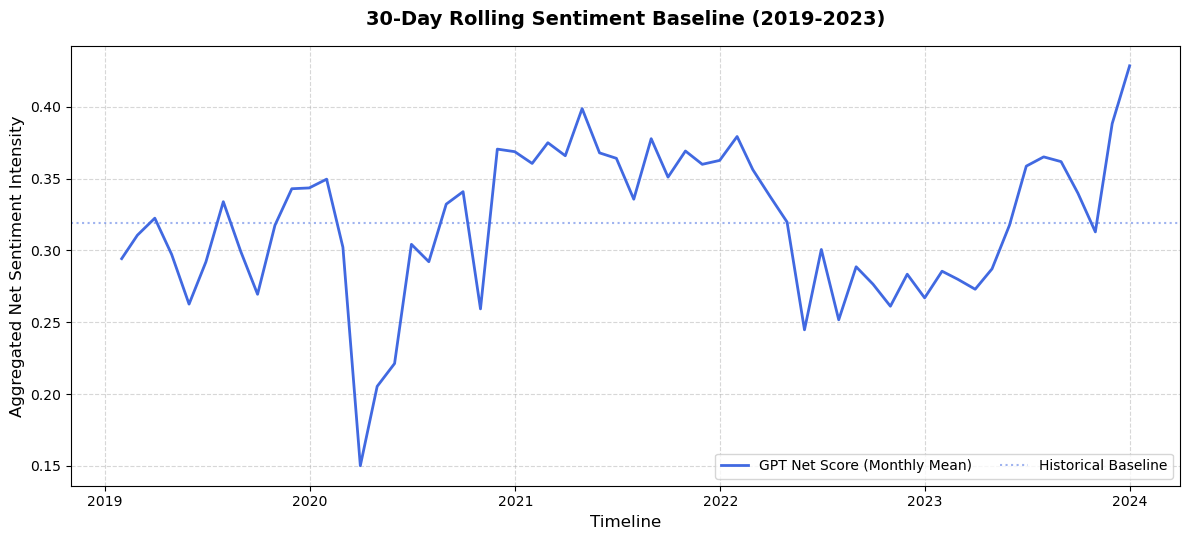

In [24]:
#Sentiment Trajectory Plot
time_df = dataset_B_final[['Date', 'gpt_net_sentiment']].copy()
time_df['Date'] = pd.to_datetime(time_df['Date'])
time_df.set_index('Date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['gpt_net_sentiment'], label='GPT Net Score (Monthly Mean)', color='royalblue', linewidth=2)
plt.axhline(y=monthly_sentiment['gpt_net_sentiment'].mean(), color='royalblue', linestyle=':', alpha=0.5, label='Historical Baseline')
plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig('finbert_macro_sentiment_timeline.png', dpi=300)
plt.show()

In [25]:
#Saving Data with Sentiment Scores
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_GPT_Sentiment_Score.csv'
output_path2 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetB_GPT_Sentiment_Score.csv'
dataset_A_final.to_csv(output_path1, index=False)
dataset_B_final.to_csv(output_path2, index=False)
print('Success!')

Success!
